# ResPlan convex decomposition pipeline

**Objective**
Load the preselected aligned ResPlan floorplans and continue directly with convex room splitting on that saved working subset.

**Inputs**
- `data/ResPlan/floorplans_aligned_quantized.pickle` produced by `ResPlan_Preprocessing.ipynb`

**Workflow overview**
1. Load the already-selected aligned-and-quantized room floorplans from the preprocessing artifact.
2. Decompose non-convex room polygons into convex pieces.
3. Expose the decomposed subset as the final export dataset and write `data/ResPlan/floorplans.pickle`.
4. Inspect fixed showcase examples and summarize convex coverage statistics.

**Key outputs**
- `floorplans_rooms_aligned_quantized`
- `floorplans_best_convex`
- `floorplans_final`
- `data/ResPlan/floorplans.pickle`


### Imports
Load only the geometry, plotting, and helper dependencies needed after preprocessing.


In [1]:
# Standard library
import os
import sys
import math
import pickle
from pathlib import Path
from typing import List, Dict, Any, Tuple
from itertools import product

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LinearRing, LineString
from shapely.ops import split


def get_project_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / ".git").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError(f"Couldn't find the ConvexDecomp project root starting at {start}")


PROJECT_ROOT = get_project_root(Path.cwd().resolve())
dataset_dir = PROJECT_ROOT / "external" / "resplan"
RESPLAN_DATA_DIR = PROJECT_ROOT / "data" / "ResPlan"
NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / "notebooks"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(dataset_dir) not in sys.path:
    sys.path.insert(0, str(dataset_dir))

from resplan_utils import plot_plan


## Load preprocessed floorplans

### Load the preselected aligned subset and inspect input diagnostics

**Inputs**
- `data/ResPlan/floorplans_aligned_quantized.pickle` from `ResPlan_Preprocessing.ipynb`
- Shared helper `notebooks.helpers.floorplan_dataset_diagnostics`

**Steps**
1. Load the saved aligned-and-quantized working subset used by this notebook.
2. Report how many room polygons the subset contains and how many are already concave.
3. Count how many samples contain at least one room below `2.0 m^2`.
4. Plot a compact row of input-distribution diagnostics before convex decomposition starts.

**Outputs**
- `floorplans_rooms_aligned_quantized`
- Printed input-dataset diagnostics and a diagnostic plot row


Loaded 2984 preselected aligned floorplans from /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/data/ResPlan/floorplans_aligned_quantized.pickle

=== ResPlan input diagnostics ===
Samples in working set: 2984
Polygons across all samples: 23632
Concave polygons before convex decomposition: 10036 / 23632 (42.5%)
Samples with at least one polygon below 2.0 m^2: 0 / 2984 (0.0%)


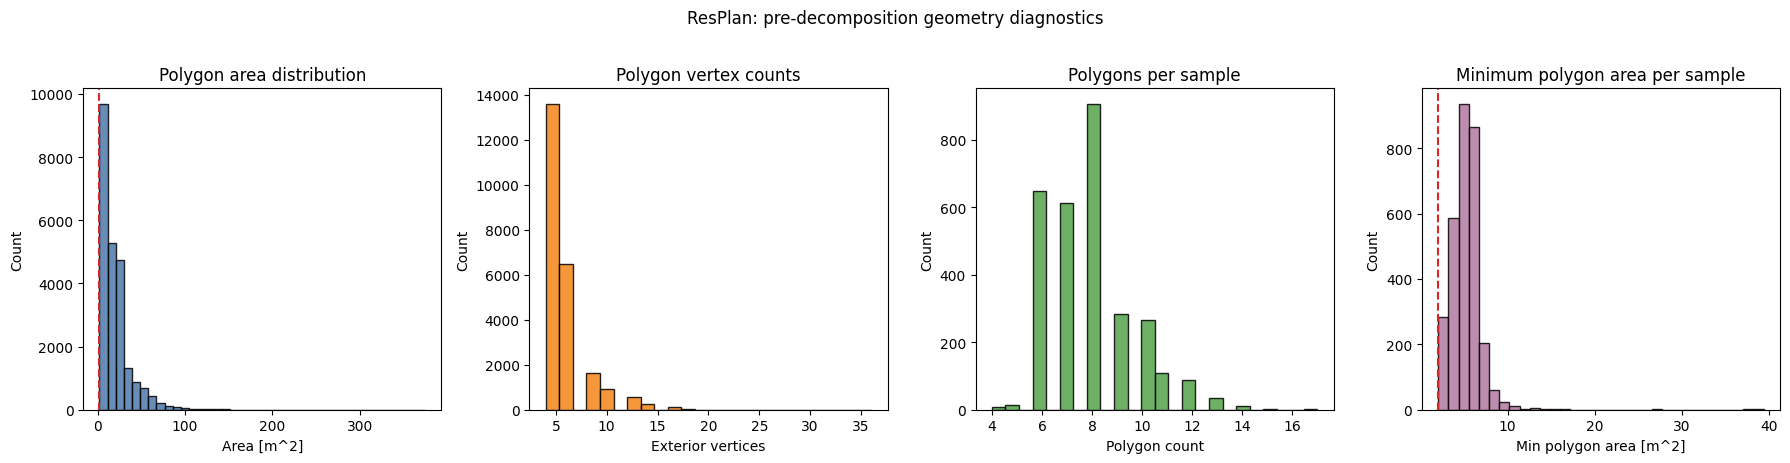

In [2]:
PREPROCESSED_INPUT_PATH = RESPLAN_DATA_DIR / "floorplans_aligned_quantized.pickle"
if not PREPROCESSED_INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Preprocessed floorplans not found at {PREPROCESSED_INPUT_PATH}. Run ResPlan_Preprocessing.ipynb first."
    )

with open(PREPROCESSED_INPUT_PATH, "rb") as f:
    floorplans_rooms_aligned_quantized = pickle.load(f)

from notebooks.helpers.floorplan_dataset_diagnostics import (
    plot_resplan_input_dataset_diagnostics,
)

print(f"Loaded {len(floorplans_rooms_aligned_quantized)} preselected aligned floorplans from {PREPROCESSED_INPUT_PATH}")
print("")
input_diag_summary, input_diag_df = plot_resplan_input_dataset_diagnostics(
    floorplans_rooms_aligned_quantized,
    room_keys=("bathroom", "bedroom", "stair", "kitchen", "storage", "living"),
    min_area_m2=2.0,
    dataset_label="ResPlan",
)


### Preview the preselected aligned room floorplans
Define a grid plotting helper and inspect the first few aligned-and-quantized plans loaded from the already-selected preprocessing artifact.


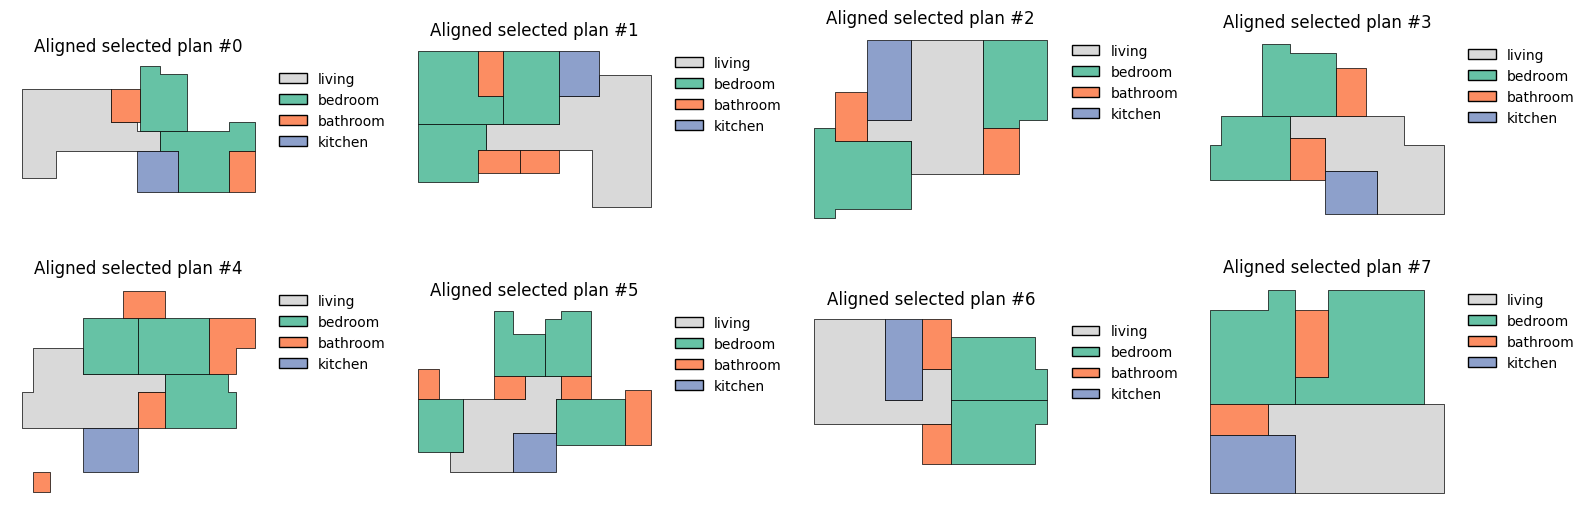

In [3]:
def plot_floorplans_grid(floorplans, ncols: int = 5, nrows: int = 2, title_prefix: str = "Plan"):
    """Plot floorplans in a grid using `plot_plan`."""
    max_plots = ncols * nrows
    n = min(len(floorplans), max_plots)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    for i in range(n):
        ax = axes[i]
        plot_plan(floorplans[i], ax=ax, legend=True, title=f"{title_prefix} #{i}")
        ax.set_axis_off()

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_floorplans_grid(floorplans_rooms_aligned_quantized, ncols=4, nrows=2, title_prefix="Aligned selected plan")


## Convex Room Split

Split all the non-convex rooms to convex pieces intelligently.


### Decompose non-convex rooms with shared H/V search diagnostics

**Inputs**
- The selected `floorplans_rooms_aligned_quantized` subset with `>= 3 concave rooms`
- Shared helpers `notebooks.helpers.resplan_convex_decomposition`, `notebooks.helpers.convex_decomposition`, `notebooks.helpers.polygon_convexity`, and `notebooks.helpers.search_diagnostics`
- Decomposition knobs `MIN_AREA_M2`, `MAX_DEPTH`, `MAX_VARIANTS_POLY`, `ADAPTIVE_INITIAL_DEPTH`, `WEIGHT_ROOMS`, `WEIGHT_COMPACT_SHOWCASE`, and `WEIGHT_COMPACT_DATASET`

**Steps**
1. Reuse the shared strict convexity helper so notebooks and scripts use the same polygon test.
2. Start each non-convex room search from a cheap depth budget, then retry with larger depth until the first successful parameter setting is found.
3. Score valid convex variants by room count and compactness, then keep the best room-wise reconstruction from that successful search setting.
4. Reuse the same helper and retry schedule for both the showcase plan and the dataset-wide run.

**Outputs**
- `best_plan`, `total_score`, `per_room`, `previews`
- `room_search_records`


[Best convex decomposition] showcase plan id=10171 (index 10)
  total score = 67.5312   (weights: rooms=1.0, compactness=20.0)
  - bathroom: score=24.9325, parts=5
  - bedroom : score=27.1858, parts=6
  - kitchen : score=5.6996, parts=1
  - living  : score=9.7133, parts=4


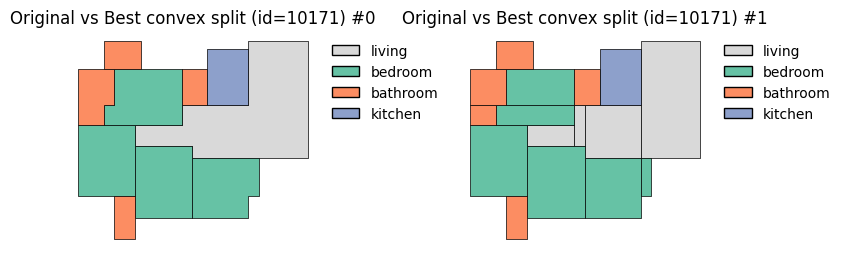

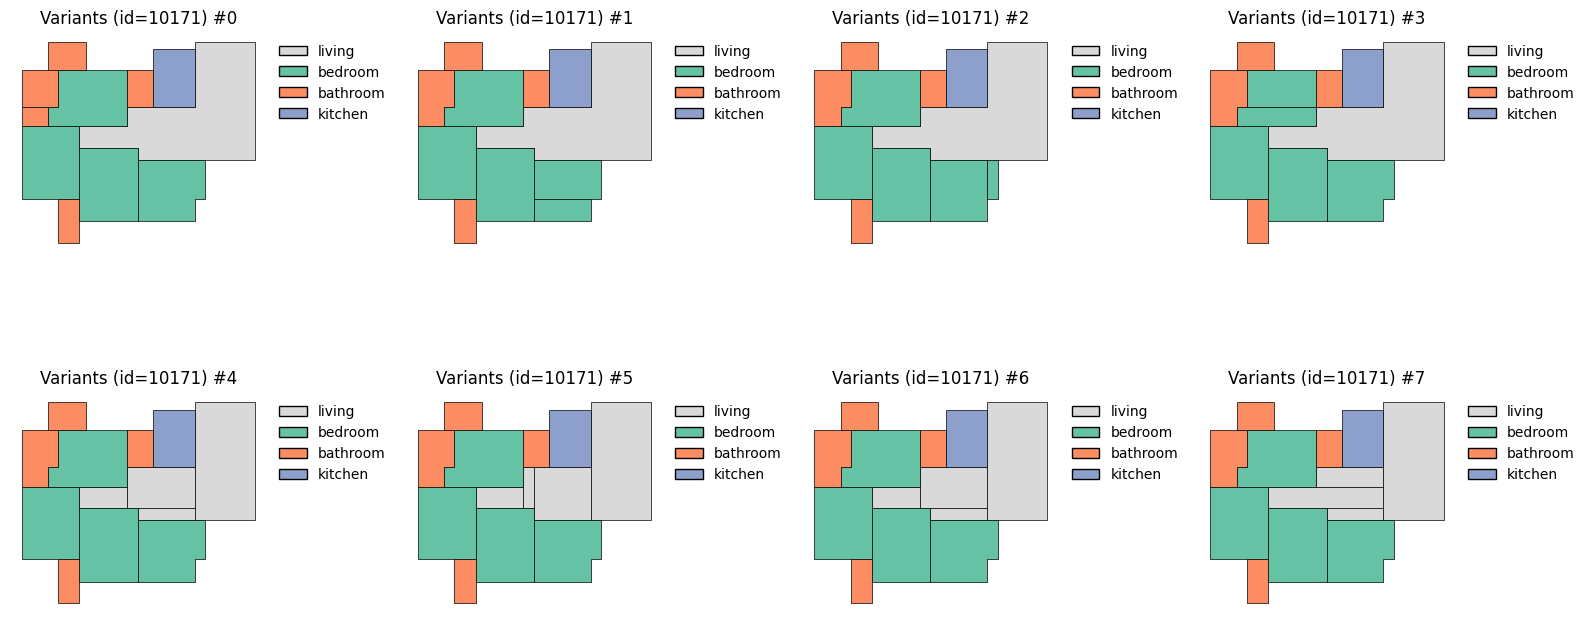

In [4]:
# === Pick the best convex decomposition per room on the first fixed showcase plan ===

from notebooks.helpers.convex_decomposition import AdaptiveSearchConfig
from notebooks.helpers.polygon_convexity import convexity_mask as shared_convexity_mask
from notebooks.helpers.resplan_convex_decomposition import (
    DEFAULT_ROOM_KEYS,
    FAILURE_REASON_LABELS,
    HVConvexDecompositionConfig,
    decompose_polygon_hv_with_diagnostics,
    pick_best_convex_variant_per_room,
)
from notebooks.helpers.search_diagnostics import plot_tree_search_distributions

# Config
SHOWCASE_PLAN_IDS = [10171, 13737, 12600]
SHOWCASE_PLAN_COUNT = 3  # Number of showcase plans to render; can exceed SHOWCASE_PLAN_IDS to allow fallback plans
PLAN_IDX = next((i for i, fp in enumerate(floorplans_rooms_aligned_quantized) if fp.get("id") in SHOWCASE_PLAN_IDS), 9)
MIN_AREA_M2 = 2.0
MAX_DEPTH = 8
MAX_VARIANTS_POLY = 64
ADAPTIVE_INITIAL_DEPTH = 4
ADAPTIVE_DEPTH_STEP = 1
WEIGHT_ROOMS = 1.0
WEIGHT_COMPACT_SHOWCASE = 20.0
WEIGHT_COMPACT_DATASET = 10.0
ROOM_KEYS = set(DEFAULT_ROOM_KEYS)

showcase_cfg = HVConvexDecompositionConfig(
    min_area_m2=MIN_AREA_M2,
    max_depth=MAX_DEPTH,
    max_variants_poly=MAX_VARIANTS_POLY,
    weight_rooms=WEIGHT_ROOMS,
    weight_compact=WEIGHT_COMPACT_SHOWCASE,
    track_time=True,
    room_keys=DEFAULT_ROOM_KEYS,
    adaptive_search=AdaptiveSearchConfig(
        enabled=True,
        initial_depth=ADAPTIVE_INITIAL_DEPTH,
        max_depth=MAX_DEPTH,
        depth_step=ADAPTIVE_DEPTH_STEP,
    ),
)
dataset_cfg = HVConvexDecompositionConfig(
    min_area_m2=MIN_AREA_M2,
    max_depth=MAX_DEPTH,
    max_variants_poly=MAX_VARIANTS_POLY,
    weight_rooms=WEIGHT_ROOMS,
    weight_compact=WEIGHT_COMPACT_DATASET,
    track_time=True,
    room_keys=DEFAULT_ROOM_KEYS,
    adaptive_search=AdaptiveSearchConfig(
        enabled=True,
        initial_depth=ADAPTIVE_INITIAL_DEPTH,
        max_depth=MAX_DEPTH,
        depth_step=ADAPTIVE_DEPTH_STEP,
    ),
)

_convexity_mask = shared_convexity_mask

# ---- Run on the selected plan, report and plot ----
plan2 = floorplans_rooms_aligned_quantized[PLAN_IDX]
best_plan, total_score, per_room, previews, room_search_records = pick_best_convex_variant_per_room(
    plan2,
    showcase_cfg,
    plot_variants=True,
    max_previews=48,
)

print(f"[Best convex decomposition] showcase plan id={plan2.get('id')} (index {PLAN_IDX})")
print(
    f"  total score = {total_score:.4f}   "
    f"(weights: rooms={showcase_cfg.weight_rooms}, compactness={showcase_cfg.weight_compact})"
)
for key, score in per_room.items():
    print(f"  - {key:8s}: score={score:.4f}, parts={len(best_plan.get(key, []))}")

plot_floorplans_grid(
    [plan2, best_plan],
    ncols=2,
    title_prefix=f"Original vs Best convex split (id={plan2.get('id')})",
)

if previews:
    plot_floorplans_grid(previews, ncols=4, nrows=3, title_prefix=f"Variants (id={plan2.get('id')})")


### Run the convex decomposition across the preselected aligned subset

**Inputs**
- `floorplans_rooms_aligned_quantized` loaded from the preprocessing artifact
- Shared H/V decomposition config `dataset_cfg` with adaptive depth retries

**Steps**
1. Reuse `pick_best_convex_variant_per_room()` for every preselected aligned plan.
2. Store the best convex reconstruction in `floorplans_best_convex`.
3. Collect room-level search diagnostics for every decomposed room search, including how many retry attempts were needed.
4. Track plan-level total score, room-part counts, remaining non-convex polygons, and the deepest successful retry level used in that plan.

**Outputs**
- `floorplans_best_convex`
- `scores_summary`
- `room_search_diagnostics_df`


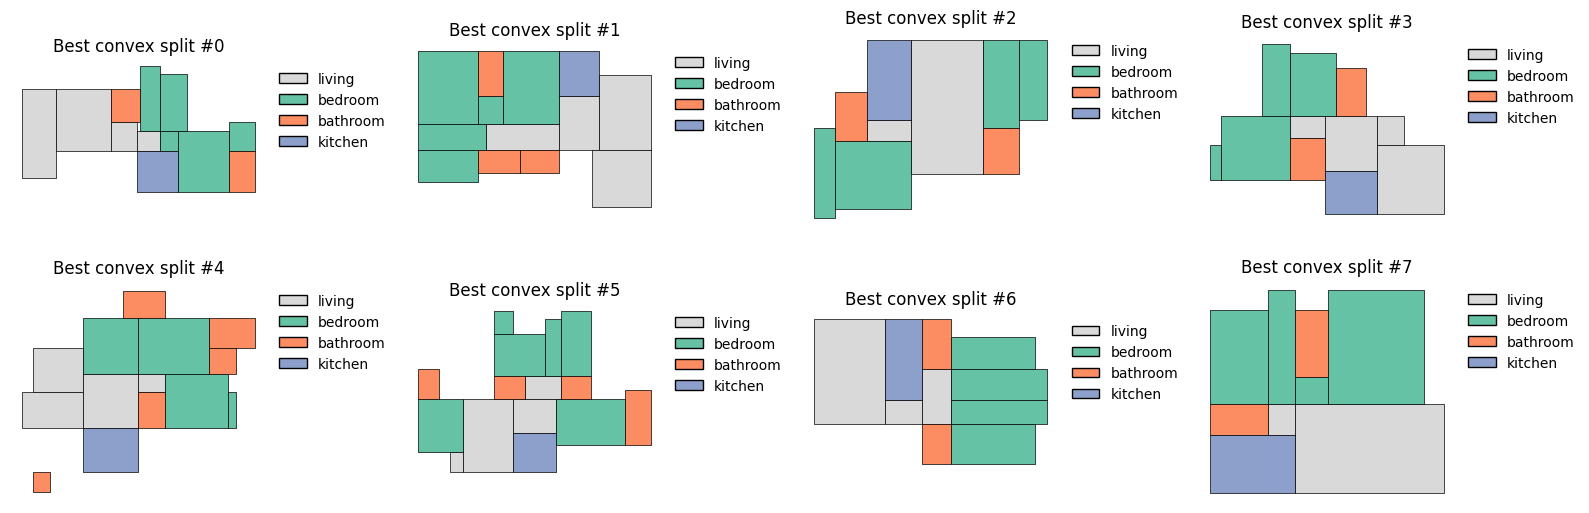

In [5]:
floorplans_best_convex = []
scores_summary = []
room_search_records_all = []

for i, plan in enumerate(floorplans_rooms_aligned_quantized):
    best_plan, total_score, per_room, _, room_records = pick_best_convex_variant_per_room(
        plan,
        dataset_cfg,
        plot_variants=False,
    )
    floorplans_best_convex.append(best_plan)
    room_search_records_all.extend(room_records)

    room_polys = [
        poly
        for key, polys in best_plan.items()
        if key in ROOM_KEYS
        for poly in polys
        if isinstance(poly, Polygon) and not poly.is_empty
    ]
    nonconvex_remaining = int((~_convexity_mask(room_polys)).sum()) if room_polys else 0
    successful_room_searches = int(sum(1 for record in room_records if record["success"]))
    failed_room_searches = int(sum(1 for record in room_records if not record["success"]))
    fallback_room_searches = int(sum(1 for record in room_records if record.get("fallback_used")))
    decomposition_time_seconds = float(sum(float(record.get("time_seconds") or 0.0) for record in room_records))
    search_attempt_counts = [int(record.get("search_attempt_count", 0) or 0) for record in room_records]
    used_depths = [
        int(record["search_depth_used"])
        for record in room_records
        if record.get("search_depth_used") is not None
    ]
    retried_room_searches = int(sum(1 for attempts in search_attempt_counts if attempts > 1))
    total_search_attempts = int(sum(search_attempt_counts))
    plan_decomposition_failed = failed_room_searches > 0

    scores_summary.append({
        "plan_idx": i,
        "plan_id": plan.get("id"),
        "total_score": total_score,
        "nonconvex_remaining": nonconvex_remaining,
        "successful_room_searches": successful_room_searches,
        "failed_room_searches": failed_room_searches,
        "fallback_room_searches": fallback_room_searches,
        "retried_room_searches": retried_room_searches,
        "total_search_attempts": total_search_attempts,
        "max_search_depth_used": max(used_depths, default=0),
        "decomposition_time_seconds": decomposition_time_seconds,
        "plan_decomposition_failed": plan_decomposition_failed,
        **{f"{key}_parts": len(best_plan.get(key, [])) for key in DEFAULT_ROOM_KEYS},
    })

scores_summary_df = pd.DataFrame(scores_summary)
room_search_diagnostics_df = pd.DataFrame(room_search_records_all)

plot_floorplans_grid(floorplans_best_convex, ncols=4, title_prefix="Best convex split")


### Expose the decomposed subset as the final dataset
Set `floorplans_final` to the convex-decomposed subset directly because geometry cleanup and minimum-room-area filtering now happen in preprocessing.


In [6]:
floorplans_final = floorplans_best_convex
print(f"Final exported dataset size: {len(floorplans_final)}")


Final exported dataset size: 2984


### Save the single final dataset
Persist the decomposed `floorplans_final` subset to `data/ResPlan/floorplans.pickle`.


In [7]:
import pickle

output_dir = RESPLAN_DATA_DIR
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "floorplans.pickle"
with open(output_path, "wb") as f:
    pickle.dump(floorplans_final, f)

print(f"Saved {len(floorplans_final)} floorplans to {output_path}")


Saved 2984 floorplans to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/data/ResPlan/floorplans.pickle


## Fixed convex decomposition showcases
Resolve a configurable number of showcase aligned plans from the selected subset, prioritize the fixed ids first, and reuse them for detailed convex split inspection and final before/after comparisons.
Set `SHOWCASE_PLAN_COUNT` in the configuration cell to control how many showcase cases are rendered.


In [8]:
resolved_showcase_ids = [pid for pid in SHOWCASE_PLAN_IDS if any(fp.get("id") == pid for fp in floorplans_rooms_aligned_quantized)]
if len(resolved_showcase_ids) < SHOWCASE_PLAN_COUNT:
    fallback_ids = [fp.get("id") for fp in floorplans_rooms_aligned_quantized if fp.get("id") not in resolved_showcase_ids]
    resolved_showcase_ids.extend(fallback_ids[: max(0, SHOWCASE_PLAN_COUNT - len(resolved_showcase_ids))])
else:
    resolved_showcase_ids = resolved_showcase_ids[:SHOWCASE_PLAN_COUNT]

if not resolved_showcase_ids:
    raise ValueError("No showcase plans are available in the preprocessing artifact.")

TARGET_ID = resolved_showcase_ids[0]
fp_aligned = next(fp for fp in floorplans_rooms_aligned_quantized if fp.get("id") == TARGET_ID)

print(f"Loaded aligned showcase plan id={TARGET_ID} for detailed convex split inspection.")


Loaded aligned showcase plan id=10171 for detailed convex split inspection.


### Inspect convex split variants for the first fixed showcase plan
Generate per-room convex split previews for the double-wall showcase example, then render fixed aligned-vs-convex comparisons for all showcase ids.


Non-convex polygons in aligned plan: 4


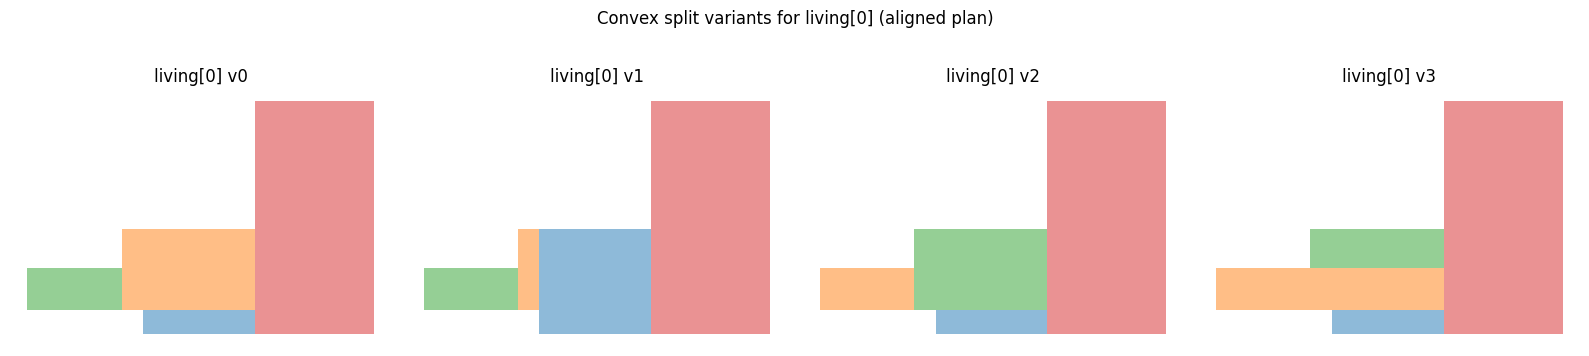

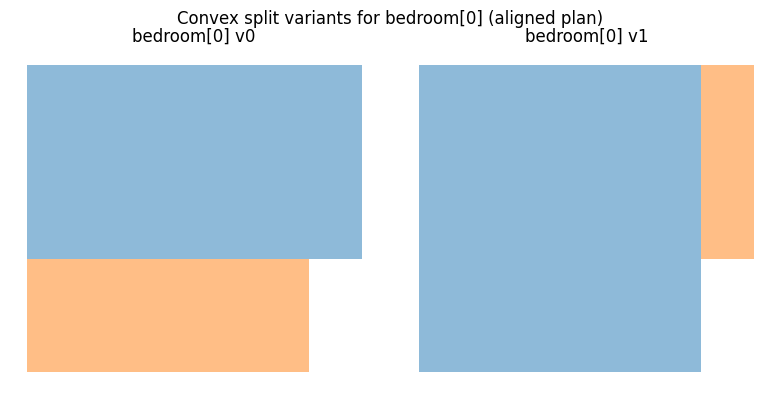

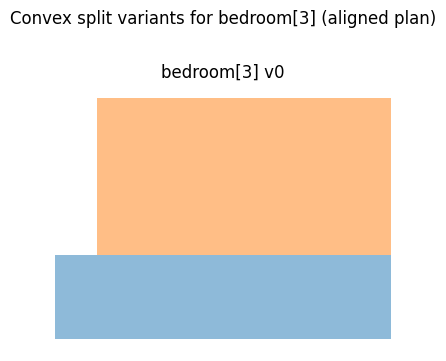

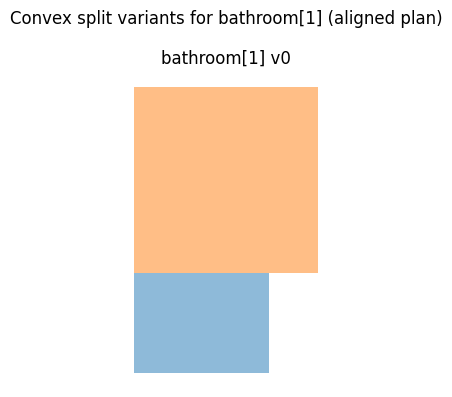

[Best convex decomposition] aligned plan id=10171
  total score = 67.5312   (weights: rooms=1.0, compactness=20.0)
  - bathroom: score=24.9325, parts=5
  - bedroom : score=27.1858, parts=6
  - kitchen : score=5.6996, parts=1
  - living  : score=9.7133, parts=4
Final convexified rooms stats:
  polygons: 16
  vertices: 80
  total_area_m2: 183.8455392003721


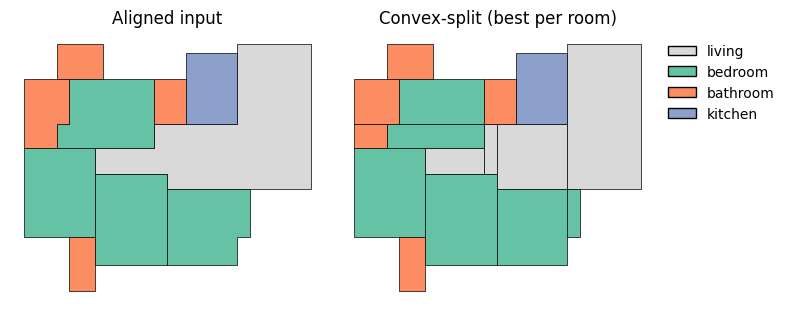

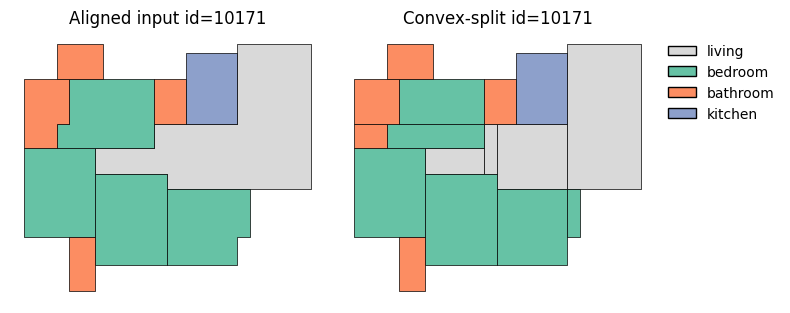

Saved convex showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_convex_splits/aligned_vs_convex_showcase_10171.svg


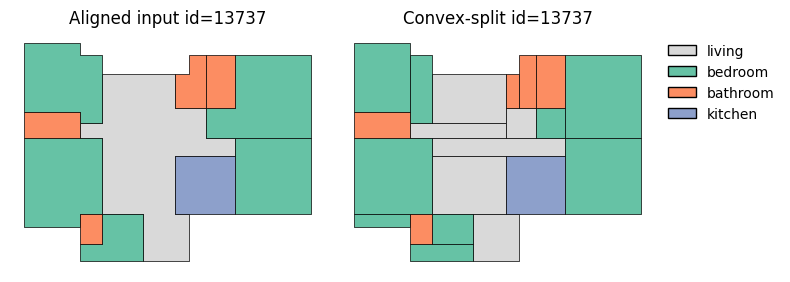

Saved convex showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_convex_splits/aligned_vs_convex_showcase_13737.svg


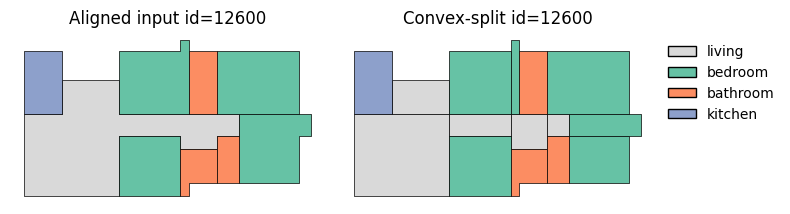

Saved convex showcase SVG to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/svg_convex_splits/aligned_vs_convex_showcase_12600.svg


In [9]:
# --- Convex room split on the aligned plan using existing helpers ---

SVG_OUT_DIR = NOTEBOOK_OUTPUT_DIR / "svg_convex_splits"
SVG_OUT_DIR.mkdir(parents=True, exist_ok=True)

plan_edge = {"id": fp_aligned.get("id")}
for rk in ROOM_KEYS:
    polys = [
        poly for poly in fp_aligned.get(rk, [])
        if isinstance(poly, Polygon) and not poly.is_empty
    ]
    if polys:
        plan_edge[rk] = polys

plan_id_str = str(plan_edge.get("id", "plan"))

room_entries = [
    (rk, j, poly)
    for rk in ROOM_KEYS
    for j, poly in enumerate(plan_edge.get(rk, []))
    if isinstance(poly, Polygon) and not poly.is_empty
]
nonconvex_mask = ~_convexity_mask([poly for _, _, poly in room_entries]) if room_entries else np.zeros(0, dtype=bool)
nonconvex = [entry for entry, keep in zip(room_entries, nonconvex_mask) if keep]

print(f"Non-convex polygons in aligned plan: {len(nonconvex)}")

for rk, j, poly in nonconvex:
    variant_records = decompose_polygon_hv_with_diagnostics(poly, showcase_cfg)["variant_records"]
    variants = [record["parts"] for record in variant_records]
    if not variants:
        continue

    n_var = len(variants)
    fig, axes = plt.subplots(1, n_var, figsize=(4 * n_var, 4))
    if n_var == 1:
        axes = [axes]

    for k, var in enumerate(variants):
        ax = axes[k]
        for part in var:
            xs, ys = part.exterior.xy
            ax.fill(xs, ys, alpha=0.5)
        ax.set_aspect("equal", "box")
        ax.set_axis_off()
        ax.set_title(f"{rk}[{j}] v{k}")

    fig.suptitle(f"Convex split variants for {rk}[{j}] (aligned plan)")
    plt.tight_layout()

    fname = f"convex_variants_{plan_id_str}_{rk}_{j}.svg"
    fig.savefig(SVG_OUT_DIR / fname, format="svg", bbox_inches="tight")
    plt.show()

best_plan, total_score, per_room_scores, previews, room_search_records_showcase = pick_best_convex_variant_per_room(
    plan_edge,
    showcase_cfg,
    plot_variants=False,
    max_previews=0,
)

print(f"[Best convex decomposition] aligned plan id={plan_edge['id']}")
print(
    f"  total score = {total_score:.4f}   "
    f"(weights: rooms={showcase_cfg.weight_rooms}, compactness={showcase_cfg.weight_compact})"
)
for key, score in per_room_scores.items():
    print(f"  - {key:8s}: score={score:.4f}, parts={len(best_plan.get(key, []))}")

fp_convex_edge = dict(fp_aligned)
for rk in ROOM_KEYS:
    if rk in best_plan:
        fp_convex_edge[rk] = best_plan[rk]

convex_poly_count = sum(len(v) for k, v in best_plan.items() if k in ROOM_KEYS)
convex_vert_count = sum(
    len(list(poly.exterior.coords))
    for k, v in best_plan.items() if k in ROOM_KEYS
    for poly in v
)
convex_area = sum(
    poly.area
    for k, v in best_plan.items() if k in ROOM_KEYS
    for poly in v
)

print("Final convexified rooms stats:")
print("  polygons:", convex_poly_count)
print("  vertices:", convex_vert_count)
print("  total_area_m2:", convex_area)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_plan(fp_aligned, ax=axes[0], legend=False, title="Aligned input")
axes[0].set_axis_off()
plot_plan(fp_convex_edge, ax=axes[1], legend=True, title="Convex-split (best per room)")
axes[1].set_axis_off()
plt.tight_layout()

fname_comp = f"aligned_vs_convex_{plan_id_str}.svg"
fig.savefig(os.path.join(SVG_OUT_DIR, fname_comp), format="svg", bbox_inches="tight")
plt.show()


for showcase_id in resolved_showcase_ids:
    fp_show = next(fp for fp in floorplans_rooms_aligned_quantized if fp.get("id") == showcase_id)
    plan_show = {"id": fp_show.get("id")}
    for rk in ROOM_KEYS:
        polys = [poly for poly in fp_show.get(rk, []) if isinstance(poly, Polygon) and not poly.is_empty]
        if polys:
            plan_show[rk] = polys

    best_show, _, _, _, _ = pick_best_convex_variant_per_room(plan_show, showcase_cfg, plot_variants=False, max_previews=0)
    fp_convex_show = dict(fp_show)
    for rk in ROOM_KEYS:
        if rk in best_show:
            fp_convex_show[rk] = best_show[rk]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    plot_plan(fp_show, ax=axes[0], legend=False, title=f"Aligned input id={showcase_id}")
    axes[0].set_axis_off()
    plot_plan(fp_convex_show, ax=axes[1], legend=True, title=f"Convex-split id={showcase_id}")
    axes[1].set_axis_off()
    plt.tight_layout()

    showcase_path = SVG_OUT_DIR / f"aligned_vs_convex_showcase_{showcase_id}.svg"
    fig.savefig(showcase_path, format="svg", bbox_inches="tight")
    plt.show()
    print(f"Saved convex showcase SVG to {showcase_path}")


### Diagnose failed convex searches across the dataset

**Inputs**
- `room_search_diagnostics_df` from the dataset-wide H/V decomposition run
- Shared `plot_tree_search_distributions()` helper
- `FAILURE_REASON_LABELS` for readable failure summaries

**Steps**
1. Plot the distributions of max branching width, max depth, and total visited states for all non-convex room searches.
2. Aggregate failed room searches into room-level and dominant plan-level failure reasons.
3. Plot 20 failed plan examples with the failed room parts highlighted clearly in red.

**Outputs**
- Search-size distribution figure
- Printed failure-reason summaries
- A 20-example failed-decomposition gallery


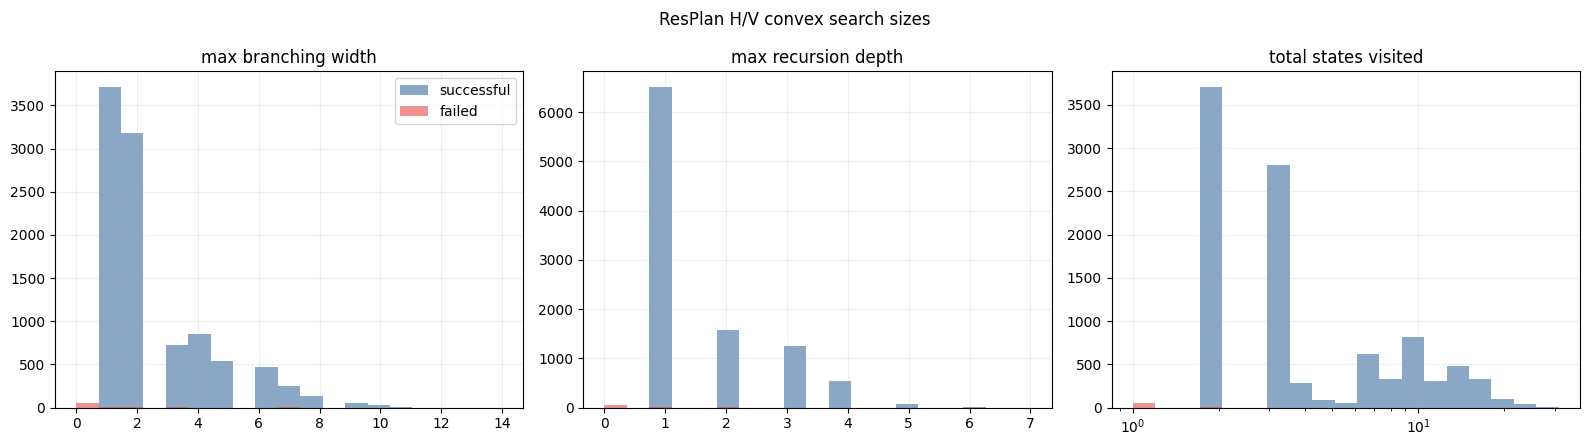

Saved tree-search distribution figure to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/resplan_tree_search_distributions.png
Fallback usage across non-convex room searches:
fallback_used
none                 9961
bisector_dead_end      75

Search stop reasons across non-convex room searches:
search_terminated_by
queue_exhausted     10029
budget_exhausted        7

Mean room-search time: 0.0079 s

=== Failed room-search reasons ===
- all feasible branches create a sub-room below 2 m²: 76 failed room searches (98.7%)
- the search hits the depth limit before reaching a fully convex split: 1 failed room searches (1.3%)

=== Dominant failed-plan reasons ===
- all feasible branches create a sub-room below 2 m²: 73 failed plans (98.6%)
- the search hits the depth limit before reaching a fully convex split: 1 failed plans (1.4%)


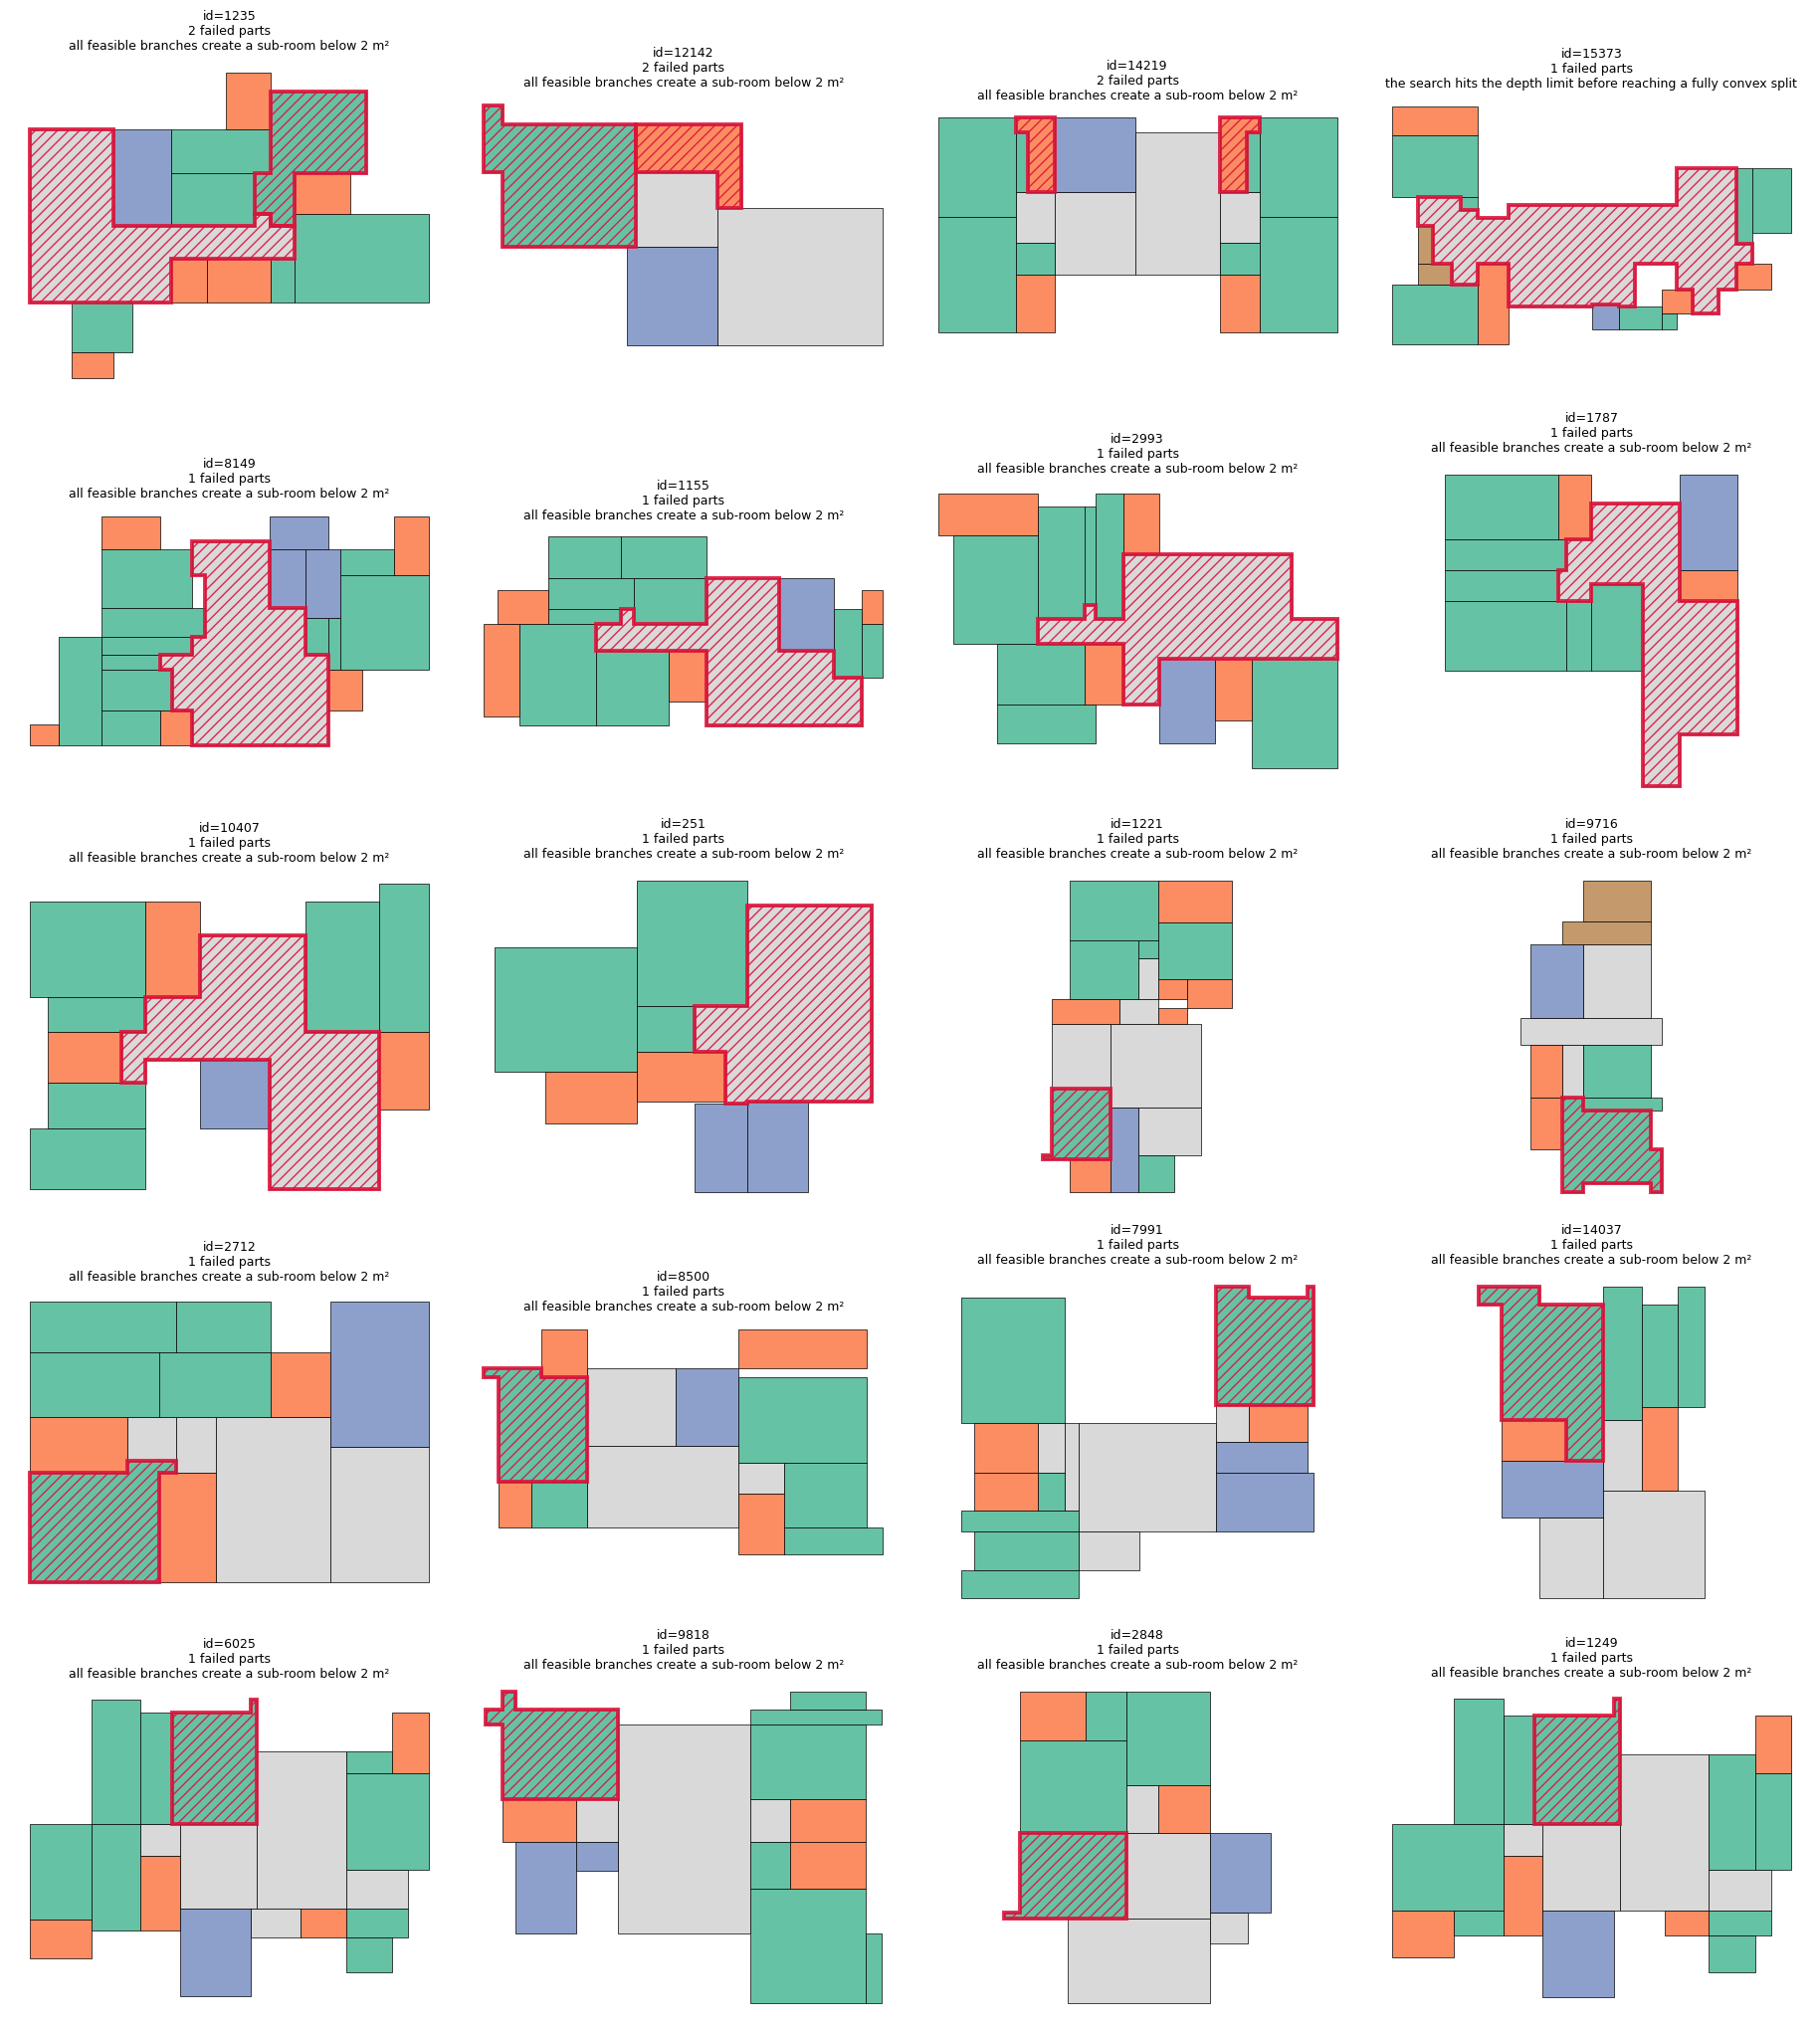


Saved failed-decomposition gallery to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/resplan_failed_decomposition_examples.png


In [10]:
nonconvex_search_df = room_search_diagnostics_df.loc[
    ~room_search_diagnostics_df["input_is_convex"]
].copy()
failed_room_search_df = nonconvex_search_df.loc[~nonconvex_search_df["success"]].copy()
failed_plan_ids_from_output = set(scores_summary_df.loc[scores_summary_df["plan_decomposition_failed"], "plan_id"])
failed_plan_ids_from_search = set(failed_room_search_df["plan_id"].unique())
residual_failed_plan_ids = sorted(failed_plan_ids_from_output - failed_plan_ids_from_search)

fig, axes = plot_tree_search_distributions(
    nonconvex_search_df,
    title_prefix="ResPlan H/V convex search sizes",
)
search_fig_path = NOTEBOOK_OUTPUT_DIR / "resplan_tree_search_distributions.png"
fig.savefig(search_fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved tree-search distribution figure to {search_fig_path}")

if failed_room_search_df.empty:
    print("No failed room decompositions were found.")
else:
    print("Fallback usage across non-convex room searches:")
    print(nonconvex_search_df["fallback_used"].fillna("none").value_counts().to_string())
    print("")
    print("Search stop reasons across non-convex room searches:")
    print(nonconvex_search_df["search_terminated_by"].fillna("missing").value_counts().to_string())
    print("")
    mean_room_time = float(nonconvex_search_df["time_seconds"].fillna(0.0).mean()) if not nonconvex_search_df.empty else 0.0
    print(f"Mean room-search time: {mean_room_time:.4f} s")
    print("")

    failed_room_reason_counts = failed_room_search_df["failure_reason"].value_counts().sort_values(ascending=False)
    print("=== Failed room-search reasons ===")
    for reason, count in failed_room_reason_counts.items():
        label = FAILURE_REASON_LABELS.get(reason, reason)
        pct = 100.0 * count / len(failed_room_search_df)
        print(f"- {label}: {count} failed room searches ({pct:.1f}%)")

    failed_plan_reason_df = (
        failed_room_search_df.groupby(["plan_id", "failure_reason"], as_index=False)["input_area_m2"]
        .sum()
        .sort_values(["plan_id", "input_area_m2"], ascending=[True, False])
    )
    dominant_failed_plan_reasons = failed_plan_reason_df.drop_duplicates("plan_id")
    failed_plan_reason_counts = dominant_failed_plan_reasons["failure_reason"].value_counts().sort_values(ascending=False)
    total_failed_plans = int(len(failed_plan_ids_from_output))

    print("\n=== Dominant failed-plan reasons ===")
    for reason, count in failed_plan_reason_counts.items():
        label = FAILURE_REASON_LABELS.get(reason, reason)
        pct = 100.0 * count / max(total_failed_plans, 1)
        print(f"- {label}: {count} failed plans ({pct:.1f}%)")
    if residual_failed_plan_ids:
        print(
            f"- residual non-convex output without a failed room search: {len(residual_failed_plan_ids)} plan(s) "
            f"({100.0 * len(residual_failed_plan_ids) / max(total_failed_plans, 1):.1f}%) -> {residual_failed_plan_ids}"
        )

    failed_examples = (
        failed_room_search_df.groupby("plan_id", as_index=False)
        .agg(
            failed_parts=("failure_reason", "size"),
            failed_area_m2=("input_area_m2", "sum"),
        )
        .sort_values(["failed_parts", "failed_area_m2", "plan_id"], ascending=[False, False, True])
        .head(20)
    )
    failed_example_ids = failed_examples["plan_id"].tolist()
    best_plan_lookup = {plan.get("id"): plan for plan in floorplans_best_convex}

    if failed_example_ids:
        n = len(failed_example_ids)
        ncols = 4
        nrows = int(math.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.1 * nrows))
        axes = np.atleast_1d(axes).flatten()

        for ax, plan_id in zip(axes, failed_example_ids):
            plan = best_plan_lookup[plan_id]
            plot_plan(plan, ax=ax, legend=False, title=f"id={plan_id}")
            failed_parts = failed_room_search_df.loc[failed_room_search_df["plan_id"] == plan_id]
            dominant_reason = dominant_failed_plan_reasons.loc[
                dominant_failed_plan_reasons["plan_id"] == plan_id, "failure_reason"
            ].iloc[0]
            for _, row in failed_parts.iterrows():
                poly = row["geometry"]
                if isinstance(poly, Polygon) and not poly.is_empty:
                    x, y = poly.exterior.xy
                    ax.fill(x, y, facecolor="none", edgecolor="crimson", linewidth=2.8, hatch="///", alpha=0.9)
            ax.set_title(
                "\n".join([
                    f"id={plan_id}",
                    f"{failed_parts.shape[0]} failed parts",
                    FAILURE_REASON_LABELS.get(dominant_reason, dominant_reason),
                ]),
                fontsize=9,
            )
            ax.set_axis_off()

        for ax in axes[n:]:
            ax.set_visible(False)

        plt.tight_layout()
        failed_fig_path = NOTEBOOK_OUTPUT_DIR / "resplan_failed_decomposition_examples.pdf"
        fig.savefig(failed_fig_path, format="pdf", bbox_inches="tight")
        plt.show()
        print(f"\nSaved failed-decomposition gallery to {failed_fig_path}")


### Summarize convex coverage and the final exported dataset

Report three dataset-level counts from the current pipeline run:
1. Plans whose post-decomposition rooms are all convex.
2. Plans whose post-decomposition rooms are all convex and all at least `MIN_AREA_M2`.
3. The single exported dataset `floorplans_final`, which is written directly from the best convex reconstruction.


In [11]:
import numpy as np


def _iter_room_polys(plan):
    for key, polys in plan.items():
        if key not in ROOM_KEYS or not isinstance(polys, list):
            continue
        for poly in polys:
            if isinstance(poly, Polygon) and not poly.is_empty:
                yield poly


def _plan_room_polys(plan):
    return list(_iter_room_polys(plan))


def _plan_has_rooms(plan) -> bool:
    return bool(_plan_room_polys(plan))


def _all_rooms_convex(plan) -> bool:
    polys = _plan_room_polys(plan)
    if not polys:
        return False
    return bool(_convexity_mask(polys).all())


def _all_rooms_above_area(plan, min_area: float) -> bool:
    polys = _plan_room_polys(plan)
    if not polys:
        return False
    areas = np.fromiter((poly.area for poly in polys), dtype=float)
    return bool((areas >= min_area).all())


N_TOTAL = len(floorplans_rooms_aligned_quantized)
convex_plan_flags = []
convex_and_big_flags = []
convex_success_flags = []
failed_plan_flags = scores_summary_df["plan_decomposition_failed"].fillna(False).astype(bool).to_numpy(dtype=bool)

for best_plan, plan_failed in zip(floorplans_best_convex, failed_plan_flags, strict=False):
    has_rooms = _plan_has_rooms(best_plan)
    is_convex = has_rooms and _all_rooms_convex(best_plan)
    convex_plan_flags.append(is_convex)
    convex_and_big_flags.append(is_convex and _all_rooms_above_area(best_plan, MIN_AREA_M2))
    convex_success_flags.append(is_convex and not plan_failed)

n_convex_plans = int(np.sum(convex_plan_flags))
n_convex_and_big = int(np.sum(convex_and_big_flags))
n_convex_success = int(np.sum(convex_success_flags))
n_failed_plans = int(np.sum(failed_plan_flags))
n_final = len(floorplans_final)

pct_convex = 100.0 * n_convex_plans / N_TOTAL if N_TOTAL else 0.0
pct_convex_big_all = 100.0 * n_convex_and_big / N_TOTAL if N_TOTAL else 0.0
pct_convex_success = 100.0 * n_convex_success / N_TOTAL if N_TOTAL else 0.0
pct_failed = 100.0 * n_failed_plans / N_TOTAL if N_TOTAL else 0.0
pct_final = 100.0 * n_final / N_TOTAL if N_TOTAL else 0.0

print("=== Dataset-level pipeline summary ===")
print(f"Loaded preselected aligned subset: {N_TOTAL}")
print(f"Plans with at least one failed room decomposition: {n_failed_plans} / {N_TOTAL} ({pct_failed:.1f}%)")
print(f"Convex after H/V decomposition: {n_convex_plans} / {N_TOTAL} ({pct_convex:.1f}%)")
print(
    f"Diagnostic check: convex and all rooms >= {MIN_AREA_M2:.1f} m^2 after decomposition: "
    f"{n_convex_and_big} / {N_TOTAL} ({pct_convex_big_all:.1f}%)"
)
print(
    f"Convex output with no failed room decomposition: "
    f"{n_convex_success} / {N_TOTAL} ({pct_convex_success:.1f}%)"
)
print(
    f"Final exported dataset (no extra post-decomposition geometry filter): "
    f"{n_final} / {N_TOTAL} ({pct_final:.1f}%)"
)


=== Dataset-level pipeline summary ===
Loaded preselected aligned subset: 2984
Plans with at least one failed room decomposition: 74 / 2984 (2.5%)
Convex after H/V decomposition: 2910 / 2984 (97.5%)
Diagnostic check: convex and all rooms >= 2.0 m^2 after decomposition: 2910 / 2984 (97.5%)
Convex output with no failed room decomposition: 2910 / 2984 (97.5%)
Final exported dataset (no extra post-decomposition geometry filter): 2984 / 2984 (100.0%)
